In [1]:
import sys
from pathlib import Path
import torch
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import PROJECT_ROOT, RANDOM_SEEDS, LEARNING_RATE, MAX_EPOCHS, WEIGHT_DECAY, EGEMAPS_DROPOUT
from config import DANN_LAMBDA_CLASS, DANN_LAMBDA_DOMAIN
from model_DANN import AD_EGE_Model_DANN, compute_alpha
from dataset import create_dataloaders
from visualization import plot_training_curves, plot_dataset_comparison


/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SOURCE_DATASET = "ADReSS"
TARGET_DATASET = "Lu"

In [3]:
LEARNING_RATE = 3e-3      # Reduced from 1.5e-3 for more stable training
MAX_EPOCHS = 60
WEIGHT_DECAY = 1e-2
EGEMAPS_DROPOUT = 0.3
DANN_LAMBDA_DOMAIN = 1

In [4]:
SOURCE_WEIGHT = 0.5  # Weight for source domain validation accuracy
TARGET_WEIGHT = 0.5  # Weight for target domain validation accuracy

MIN_SOURCE_ACC = 0.60  # Minimum required source domain validation accuracy (lower than XLSR)
MIN_TARGET_ACC = 0.50  # Minimum required target domain validation accuracy (lower than XLSR)

# Class weights for handling imbalance (aligned with Baseline)
CLASS_WEIGHT_CONTROL = 1.1
CLASS_WEIGHT_DEMENTIA = 1.0

DOMAIN_WARMUP_EPOCHS = 5    # First 5 epochs train only source domain classifier (increased from 0)
DOMAIN_ANNEAL_RATIO = 0

BATCH_SIZE = 12

device = torch.device('cpu')

In [5]:
data_dir = PROJECT_ROOT / "data" / "processed"

SOURCE_TRAIN_CSV = data_dir / f"{SOURCE_DATASET}-egemaps-train.csv"
SOURCE_VAL_CSV = data_dir / f"{SOURCE_DATASET}-egemaps-val.csv"
TARGET_TRAIN_CSV = data_dir / f"{TARGET_DATASET}-egemaps-train.csv"
TARGET_VAL_CSV = data_dir / f"{TARGET_DATASET}-egemaps-val.csv"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / f"DANN_{SOURCE_DATASET}_to_{TARGET_DATASET}_egemaps"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Source Train: {SOURCE_TRAIN_CSV}")
print(f"Source Val: {SOURCE_VAL_CSV}")
print(f"Target Train: {TARGET_TRAIN_CSV}")
print(f"Target Val: {TARGET_VAL_CSV}")
print(f"Output Dir: {MODEL_OUTPUT_DIR}")


Source Train: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/ADReSS-egemaps-train.csv
Source Val: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/ADReSS-egemaps-val.csv
Target Train: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/Lu-egemaps-train.csv
Target Val: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/Lu-egemaps-val.csv
Output Dir: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/DANN_ADReSS_to_Lu_egemaps


## 1 Load Data


In [6]:
source_train_loader = create_dataloaders(data_csv=SOURCE_TRAIN_CSV, batch_size=BATCH_SIZE, xlsr=False)
source_val_loader = create_dataloaders(data_csv=SOURCE_VAL_CSV, batch_size=BATCH_SIZE, xlsr=False)
target_train_loader = create_dataloaders(data_csv=TARGET_TRAIN_CSV, batch_size=BATCH_SIZE, xlsr=False)
target_val_loader = create_dataloaders(data_csv=TARGET_VAL_CSV, batch_size=BATCH_SIZE, xlsr=False)


Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 32 samples
Control: 16, Dementia: 16


Loading completed: 58 samples
Control: 28, Dementia: 30


Loading completed: 16 samples
Control: 8, Dementia: 8




## 2 Model Architecture


In [7]:
test_model = AD_EGE_Model_DANN(dim_input=25, dim_hidden=32, dropout=EGEMAPS_DROPOUT)
print(f"Model created successfully!")
print(f"Feature Extractor: 25 -> 64 -> 32 (aligned with Baseline)")
print(f"Class Classifier: 32 -> 2")
print(f"Domain Classifier: 32 -> 64 -> 32 -> 2")

Model created successfully!
Feature Extractor: 25 -> 64 -> 32 (aligned with Baseline)
Class Classifier: 32 -> 2
Domain Classifier: 32 -> 64 -> 32 -> 2


## 3 Define Training Functions


In [8]:
def compute_domain_lambda(epoch, total_epochs, base_lambda=DANN_LAMBDA_DOMAIN,
                         warmup_epochs=DOMAIN_WARMUP_EPOCHS, anneal_ratio=DOMAIN_ANNEAL_RATIO):
    """Schedule domain loss weight based on epoch.
    - Warmup phase: First warmup_epochs epochs, lambda=0, train only source domain classifier
    - Then linearly increase to base_lambda over anneal_ratio proportion of epochs
    - Remaining phase: Maintain base_lambda
    """
    warmup_epochs = min(warmup_epochs, total_epochs)
    anneal_epochs = int(total_epochs * anneal_ratio)
    if epoch <= warmup_epochs:
        return 0.0
    if anneal_epochs <= 0:
        return base_lambda
    progress = min(1.0, max(0, epoch - warmup_epochs) / max(1, anneal_epochs))
    return base_lambda * progress


In [9]:
def train_one_epoch_dann(model, source_loader, target_loader, optimizer, device, epoch, total_epochs, 
                         lambda_class=DANN_LAMBDA_CLASS, lambda_domain=DANN_LAMBDA_DOMAIN):
    """Train one epoch with DANN
    
    Args:
        lambda_class: Classification loss weight (default: 1.0)
        lambda_domain: Domain adversarial loss weight for current epoch
    """
    model.train()
    
    # Class weights for handling imbalance (aligned with Baseline)
    class_weights = torch.tensor([CLASS_WEIGHT_CONTROL, CLASS_WEIGHT_DEMENTIA]).to(device)
    
    total_class_loss = 0
    total_domain_loss = 0
    correct = 0
    total = 0
    domain_correct = 0
    domain_total = 0
    
    target_iter = iter(target_loader)
    len_source = len(source_loader)
    total_steps = total_epochs * len_source
    lambda_active = lambda_domain > 0
    
    pbar = tqdm(enumerate(source_loader), total=len_source, desc=f"Epoch {epoch}", leave=False)
    
    for i, source_batch in pbar:
        # Compute alpha (gradient reversal strength)
        current_step = (epoch - 1) * len_source + i
        alpha = compute_alpha(current_step, total_steps)
        
        # ===== Process source domain data =====
        source_features, source_labels = source_batch
        source_features = source_features.to(device)
        source_labels = source_labels.to(device)
        
        if lambda_active:
            class_output, domain_output = model(
                source_features,
                mask=None,  # eGeMAPS doesn't need mask
                alpha=alpha,
                return_features=True
            )
        else:
            class_output = model(
                source_features,
                mask=None,
                alpha=alpha,
                return_features=False
            )
            domain_output = None
        
        # Source domain label = 0
        source_domain_labels = torch.zeros(source_labels.size(0), dtype=torch.long).to(device)
        
        # Compute classification loss with class weights
        loss_class = F.cross_entropy(class_output, source_labels, weight=class_weights)
        
        if lambda_active:
            loss_domain_source = F.cross_entropy(domain_output, source_domain_labels)
            try:
                target_batch = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                target_batch = next(target_iter)
            target_features, _ = target_batch  # Don't use target labels
            target_features = target_features.to(device)
            
            _, domain_output_target = model(
                target_features,
                mask=None,
                alpha=alpha,
                return_features=True
            )
            target_domain_labels = torch.ones(target_features.size(0), dtype=torch.long).to(device)
            loss_domain_target = F.cross_entropy(domain_output_target, target_domain_labels)
        else:
            loss_domain_source = torch.zeros(1, device=device)
            loss_domain_target = torch.zeros(1, device=device)
            target_domain_labels = None
            domain_output_target = None
        
        total_batch_loss = (lambda_class * loss_class +
                           lambda_domain * (loss_domain_source + loss_domain_target))
        
        optimizer.zero_grad()
        total_batch_loss.backward()
        optimizer.step()
        
        total_class_loss += loss_class.item()
        total_domain_loss += (loss_domain_source.item() + loss_domain_target.item())
        
        predictions = torch.argmax(class_output, dim=1)
        correct += (predictions == source_labels).sum().item()
        total += source_labels.size(0)
        
        if lambda_active:
            domain_pred_source = torch.argmax(domain_output, dim=1)
            domain_pred_target = torch.argmax(domain_output_target, dim=1)
            domain_correct += (domain_pred_source == source_domain_labels).sum().item()
            domain_correct += (domain_pred_target == target_domain_labels).sum().item()
            domain_total += source_domain_labels.size(0) + target_domain_labels.size(0)
        
        pbar.set_postfix({
            'α': f'{alpha:.2f}',
            'λ_dom': f'{lambda_domain:.3f}',
            'cls': f'{loss_class.item():.3f}',
            'dom': f'{(loss_domain_source.item() + loss_domain_target.item()):.3f}',
            'acc': f'{correct/total:.3f}'
        })
    
    avg_class_loss = total_class_loss / len_source
    avg_domain_loss = total_domain_loss / len_source
    train_acc = correct / total
    domain_acc = (domain_correct / domain_total) if domain_total > 0 else 0.0
    
    return avg_class_loss, avg_domain_loss, train_acc, domain_acc

In [10]:
def validate_dann(model, val_loader, device):
    """Validate DANN model"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    control_correct, control_total = 0, 0
    dementia_correct, dementia_total = 0, 0
    tp, fp, fn = 0, 0, 0
    
    with torch.no_grad():
        for features, labels in val_loader:
            features = features.to(device)
            labels = labels.to(device)
            
            logits = model(features, mask=None, return_features=False)
            
            loss = F.cross_entropy(logits, labels)
            predictions = torch.argmax(logits, dim=1)
            
            total_loss += loss.item()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            
            for pred, label in zip(predictions, labels):
                if label == 0:
                    control_total += 1
                    if pred == label:
                        control_correct += 1
                else:
                    dementia_total += 1
                    if pred == label:
                        dementia_correct += 1
                
                if pred == 1 and label == 1:
                    tp += 1
                elif pred == 1 and label == 0:
                    fp += 1
                elif pred == 0 and label == 1:
                    fn += 1
    
    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total
    control_acc = control_correct / control_total if control_total > 0 else 0
    dementia_acc = dementia_correct / dementia_total if dementia_total > 0 else 0
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return avg_loss, accuracy, control_acc, dementia_acc, f1_score


In [11]:
def train_dann(seed, source_train_loader, target_train_loader, source_val_loader, target_val_loader, 
               output_dir, device, source_weight=0.5, target_weight=0.5, 
               min_source_acc=0.0, min_target_acc=0.0):
    """Complete DANN training pipeline
    
    Args:
        min_source_acc: Minimum required source domain validation accuracy for best model selection
        min_target_acc: Minimum required target domain validation accuracy for best model selection
    """
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    
    seed_dir = Path(output_dir) / f"seed_{seed}"
    seed_dir.mkdir(parents=True, exist_ok=True)
    
    model = AD_EGE_Model_DANN(dim_input=25, dim_hidden=32, dropout=EGEMAPS_DROPOUT).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    history = {
        'epochs': [],
        'train_class_losses': [],
        'train_domain_losses': [],
        'train_accs': [],
        'source_val_accs': [],
        'target_val_accs': [],
        'avg_val_accs': [],
        'val_losses': [],
        'val_accs': [],
        'domain_accs': [],
        'lambda_domains': []
    }
    
    best_avg_acc = 0
    best_metrics = {}
    threshold_met = False  # Track if threshold was ever met
    
    print(f"\n{'='*60}")
    print(f"Training Seed {seed}")
    print(f"Model Selection: Average Accuracy (Source {source_weight:.3f}, Target {target_weight:.3f})")
    print(f"Accuracy Thresholds: Source >= {min_source_acc:.2f}, Target >= {min_target_acc:.2f}")
    print(f"{'='*60}")
    
    for epoch in range(1, MAX_EPOCHS + 1):
        current_lambda_domain = compute_domain_lambda(epoch, MAX_EPOCHS)
        class_loss, domain_loss, train_acc, domain_acc = train_one_epoch_dann(
            model, source_train_loader, target_train_loader, optimizer, device, epoch, MAX_EPOCHS,
            lambda_class=DANN_LAMBDA_CLASS,
            lambda_domain=current_lambda_domain
        )
        
        source_val_loss, source_val_acc, source_control_acc, source_dementia_acc, source_f1 = validate_dann(
            model, source_val_loader, device
        )
        
        target_val_loss, target_val_acc, target_control_acc, target_dementia_acc, target_f1 = validate_dann(
            model, target_val_loader, device
        )
        
        avg_val_acc = source_weight * source_val_acc + target_weight * target_val_acc
        
        history['epochs'].append(epoch)
        history['train_class_losses'].append(class_loss)
        history['train_domain_losses'].append(domain_loss)
        history['train_accs'].append(train_acc)
        history['source_val_accs'].append(source_val_acc)
        history['target_val_accs'].append(target_val_acc)
        history['avg_val_accs'].append(avg_val_acc)
        history['val_losses'].append(target_val_loss)
        history['val_accs'].append(target_val_acc)
        history['domain_accs'].append(domain_acc)
        history['lambda_domains'].append(current_lambda_domain)
        
        print(f"Epoch {epoch:3d} | Train: {train_acc:.3f} | Source Val: {source_val_acc:.3f} | "
              f"Target Val: {target_val_acc:.3f} | Avg: {avg_val_acc:.3f} | Domain: {domain_acc:.3f} | "
              f"λ_dom: {current_lambda_domain:.3f}")
        
        # Check if current model meets all criteria: better avg_val_acc AND meets minimum accuracy thresholds
        if (avg_val_acc > best_avg_acc and 
            source_val_acc >= min_source_acc and 
            target_val_acc >= min_target_acc):
            threshold_met = True
            best_avg_acc = avg_val_acc
            best_metrics = {
                'avg_val_acc': avg_val_acc,
                'source_val_acc': source_val_acc,
                'target_val_acc': target_val_acc,
                'source_val_loss': source_val_loss,
                'target_val_loss': target_val_loss,
                'source_control_acc': source_control_acc,
                'source_dementia_acc': source_dementia_acc,
                'target_control_acc': target_control_acc,
                'target_dementia_acc': target_dementia_acc,
                'source_f1': source_f1,
                'target_f1': target_f1,
                'epoch': epoch
            }
            torch.save(model.state_dict(), seed_dir / 'best_dann.pth')
        # If no threshold met yet, save best model so far (relaxed criteria)
        elif not threshold_met and avg_val_acc > best_avg_acc:
            best_avg_acc = avg_val_acc
            best_metrics = {
                'avg_val_acc': avg_val_acc,
                'source_val_acc': source_val_acc,
                'target_val_acc': target_val_acc,
                'source_val_loss': source_val_loss,
                'target_val_loss': target_val_loss,
                'source_control_acc': source_control_acc,
                'source_dementia_acc': source_dementia_acc,
                'target_control_acc': target_control_acc,
                'target_dementia_acc': target_dementia_acc,
                'source_f1': source_f1,
                'target_f1': target_f1,
                'epoch': epoch
            }
            torch.save(model.state_dict(), seed_dir / 'best_dann.pth')
    
    if best_metrics:
        print(f"\nBest Results (Epoch {best_metrics['epoch']}):")
        print(f"  Avg Acc: {best_metrics['avg_val_acc']*100:.2f}%")
        print(f"  Source ({SOURCE_DATASET}): {best_metrics['source_val_acc']*100:.2f}% | F1: {best_metrics['source_f1']:.4f}")
        print(f"  Target ({TARGET_DATASET}): {best_metrics['target_val_acc']*100:.2f}% | F1: {best_metrics['target_f1']:.4f}")
        if not threshold_met:
            print(f"Note: No epoch met the minimum accuracy thresholds")
            print(f"(Source >= {min_source_acc:.2f}, Target >= {min_target_acc:.2f})")
    else:
        print(f"\n Warning: No model was saved!")
    
    return seed, best_metrics, history

In [12]:
def evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device):
    """Evaluate model performance on both datasets and visualize"""
    print(f"{'='*60}")
    print(f"Evaluating Best Model (Seed {seed})")
    print(f"{'='*60}")
 
    best_model = AD_EGE_Model_DANN(dim_input=25, dim_hidden=32, dropout=EGEMAPS_DROPOUT).to(device)
    best_model.load_state_dict(torch.load(model_path, map_location=device))
    
    source_loss, source_acc, source_control_acc, source_dementia_acc, source_f1 = validate_dann(
        best_model, source_val_loader, device
    )
    target_loss, target_acc, target_control_acc, target_dementia_acc, target_f1 = validate_dann(
        best_model, target_val_loader, device
    )
    
    print(f"{'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
    print(f"{'-'*85}")
    print(f"{f'{SOURCE_DATASET} (source domain)':<25} {source_acc*100:>10.2f}%  {source_f1:>10.4f}  {source_dementia_acc*100:>10.2f}%  {source_control_acc*100:>10.2f}%  {source_loss:>8.4f}")
    print(f"{f'{TARGET_DATASET} (target domain)':<25} {target_acc*100:>10.2f}%  {target_f1:>10.4f}  {target_dementia_acc*100:>10.2f}%  {target_control_acc*100:>10.2f}%  {target_loss:>8.4f}")
    print(f"{'-'*85}")
    
    # Visualize accuracy comparison
    dataset_names = [f'{SOURCE_DATASET} (source)', f'{TARGET_DATASET} (target)']
    accuracies = [source_acc * 100, target_acc * 100]
    
    custom_colors = {
        f'{SOURCE_DATASET} (source)': '#3498db',
        f'{TARGET_DATASET} (target)': '#e74c3c'
    }
    
    plot_dataset_comparison(
        dataset_names=dataset_names,
        accuracies=accuracies,
        title=f'eGeMAPS-DANN Performance Comparison (Seed {seed})',
        custom_colors=custom_colors
    )
    
    source_metrics = {
        'acc': source_acc, 'f1': source_f1,
        'dementia_acc': source_dementia_acc,
        'control_acc': source_control_acc,
        'loss': source_loss
    }
    target_metrics = {
        'acc': target_acc, 'f1': target_f1,
        'dementia_acc': target_dementia_acc,
        'control_acc': target_control_acc,
        'loss': target_loss
    }
    return source_metrics, target_metrics


## 4 Training with Multiple Seeds


In [13]:
all_results = {
    'seeds': [],
    'metrics': [],
    'histories': [],
    'source_metrics': [],
    'target_metrics': []
}


### Seed 21



Training Seed 21
Model Selection: Average Accuracy (Source 0.500, Target 0.500)
Accuracy Thresholds: Source >= 0.60, Target >= 0.50


Epoch   1 | Train: 0.548 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.573 | Source Val: 0.625 | Target Val: 0.500 | Avg: 0.562 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.597 | Source Val: 0.531 | Target Val: 0.375 | Avg: 0.453 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.653 | Source Val: 0.562 | Target Val: 0.375 | Avg: 0.469 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  56 | Train: 0.758 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.460 | λ_dom: 1.000


Epoch  57 | Train: 0.790 | Source Val: 0.438 | Target Val: 0.500 | Avg: 0.469 | Domain: 0.488 | λ_dom: 1.000


Epoch  58 | Train: 0.766 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.488 | λ_dom: 1.000


Epoch  59 | Train: 0.718 | Source Val: 0.656 | Target Val: 0.312 | Avg: 0.484 | Domain: 0.544 | λ_dom: 1.000


Epoch  60 | Train: 0.750 | Source Val: 0.594 | Target Val: 0.250 | Avg: 0.422 | Domain: 0.488 | λ_dom: 1.000

Best Results (Epoch 29):
  Avg Acc: 62.50%
  Source (ADReSS): 62.50% | F1: 0.6000
  Target (Lu): 62.50% | F1: 0.5714


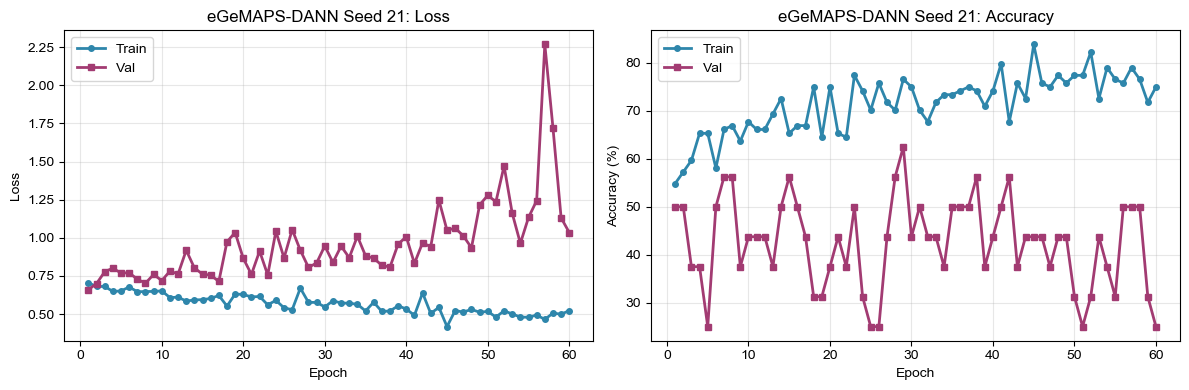

In [14]:
seed, metrics, history = train_dann(
    seed=21,
    source_train_loader=source_train_loader,
    target_train_loader=target_train_loader,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC
)

all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)

plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_class_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'eGeMAPS-DANN Seed {seed}'
)


Evaluating Best Model (Seed 21)
Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         62.50%      0.6000       56.25%       68.75%    0.7440
Lu (target domain)             62.50%      0.5714       50.00%       75.00%    0.7521
-------------------------------------------------------------------------------------


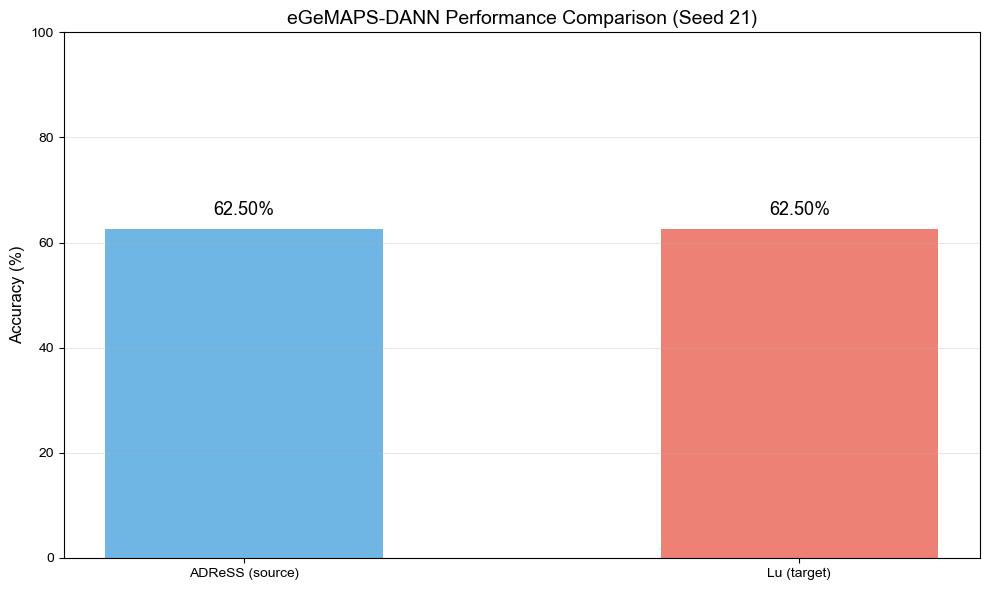

In [15]:
model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann.pth"
source_metrics, target_metrics = evaluate_and_visualize(
    seed, source_val_loader, target_val_loader, model_path, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


### Seed 42



Training Seed 42
Model Selection: Average Accuracy (Source 0.500, Target 0.500)
Accuracy Thresholds: Source >= 0.60, Target >= 0.50


Epoch   1 | Train: 0.484 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.669 | Source Val: 0.469 | Target Val: 0.625 | Avg: 0.547 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.581 | Source Val: 0.531 | Target Val: 0.500 | Avg: 0.516 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.613 | Source Val: 0.406 | Target Val: 0.562 | Avg: 0.484 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  56 | Train: 0.726 | Source Val: 0.469 | Target Val: 0.375 | Avg: 0.422 | Domain: 0.524 | λ_dom: 1.000


Epoch  57 | Train: 0.766 | Source Val: 0.500 | Target Val: 0.438 | Avg: 0.469 | Domain: 0.504 | λ_dom: 1.000


Epoch  58 | Train: 0.758 | Source Val: 0.531 | Target Val: 0.500 | Avg: 0.516 | Domain: 0.480 | λ_dom: 1.000


Epoch  59 | Train: 0.750 | Source Val: 0.500 | Target Val: 0.438 | Avg: 0.469 | Domain: 0.472 | λ_dom: 1.000


Epoch  60 | Train: 0.782 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.516 | λ_dom: 1.000

Best Results (Epoch 13):
  Avg Acc: 56.25%
  Source (ADReSS): 56.25% | F1: 0.5625
  Target (Lu): 56.25% | F1: 0.5882
Note: No epoch met the minimum accuracy thresholds
(Source >= 0.60, Target >= 0.50)


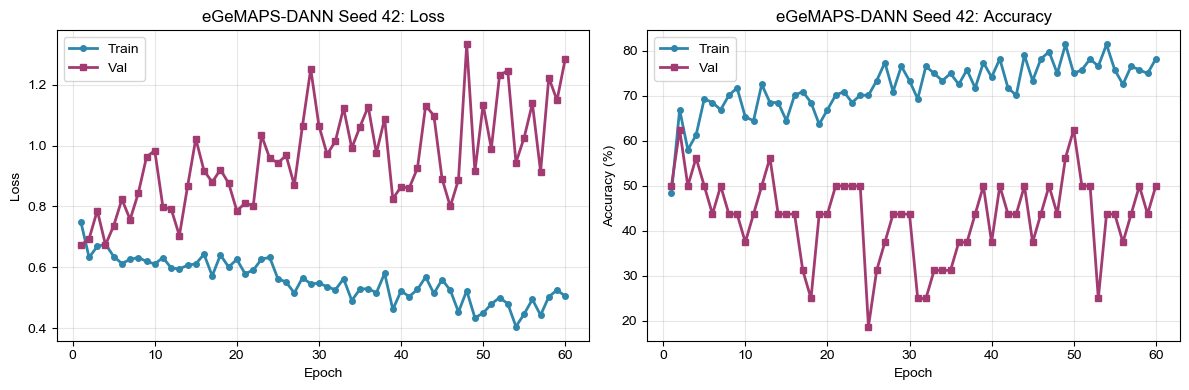

Evaluating Best Model (Seed 42)
Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         56.25%      0.5625       56.25%       56.25%    0.7800
Lu (target domain)             56.25%      0.5882       62.50%       50.00%    0.7569
-------------------------------------------------------------------------------------


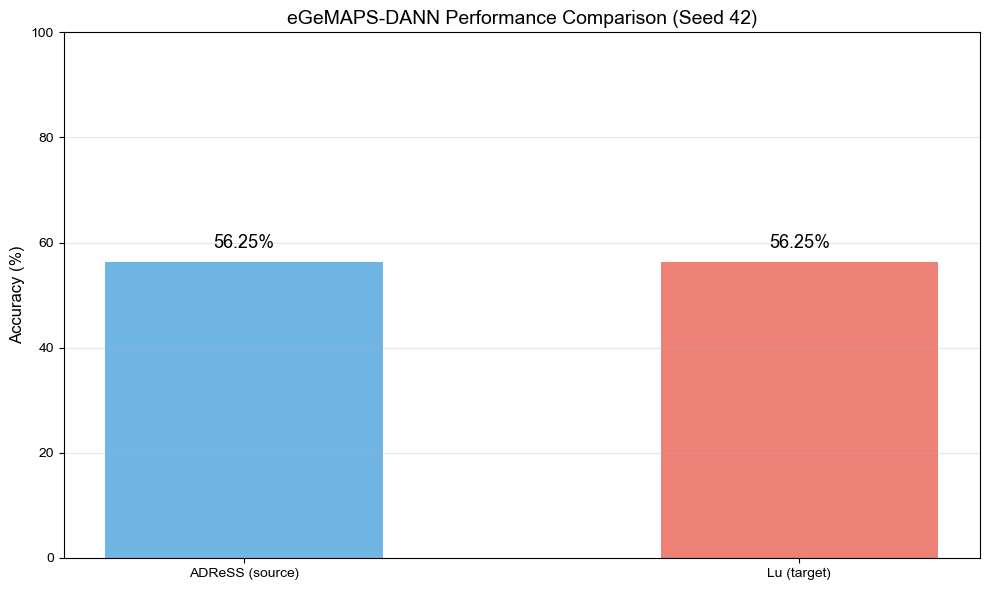

In [16]:
seed, metrics, history = train_dann(42, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT,
                                     min_source_acc=MIN_SOURCE_ACC, min_target_acc=MIN_TARGET_ACC)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'eGeMAPS-DANN Seed {seed}')

model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


### Seed 84



Training Seed 84
Model Selection: Average Accuracy (Source 0.500, Target 0.500)
Accuracy Thresholds: Source >= 0.60, Target >= 0.50


Epoch   1 | Train: 0.532 | Source Val: 0.312 | Target Val: 0.438 | Avg: 0.375 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.565 | Source Val: 0.531 | Target Val: 0.188 | Avg: 0.359 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.661 | Source Val: 0.469 | Target Val: 0.438 | Avg: 0.453 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.710 | Source Val: 0.438 | Target Val: 0.438 | Avg: 0.438 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  56 | Train: 0.750 | Source Val: 0.406 | Target Val: 0.125 | Avg: 0.266 | Domain: 0.500 | λ_dom: 1.000


Epoch  57 | Train: 0.774 | Source Val: 0.500 | Target Val: 0.188 | Avg: 0.344 | Domain: 0.472 | λ_dom: 1.000


Epoch  58 | Train: 0.806 | Source Val: 0.469 | Target Val: 0.375 | Avg: 0.422 | Domain: 0.563 | λ_dom: 1.000


Epoch  59 | Train: 0.766 | Source Val: 0.438 | Target Val: 0.250 | Avg: 0.344 | Domain: 0.500 | λ_dom: 1.000


Epoch  60 | Train: 0.742 | Source Val: 0.438 | Target Val: 0.438 | Avg: 0.438 | Domain: 0.532 | λ_dom: 1.000

Best Results (Epoch 8):
  Avg Acc: 53.12%
  Source (ADReSS): 56.25% | F1: 0.6316
  Target (Lu): 50.00% | F1: 0.6000
Note: No epoch met the minimum accuracy thresholds
(Source >= 0.60, Target >= 0.50)


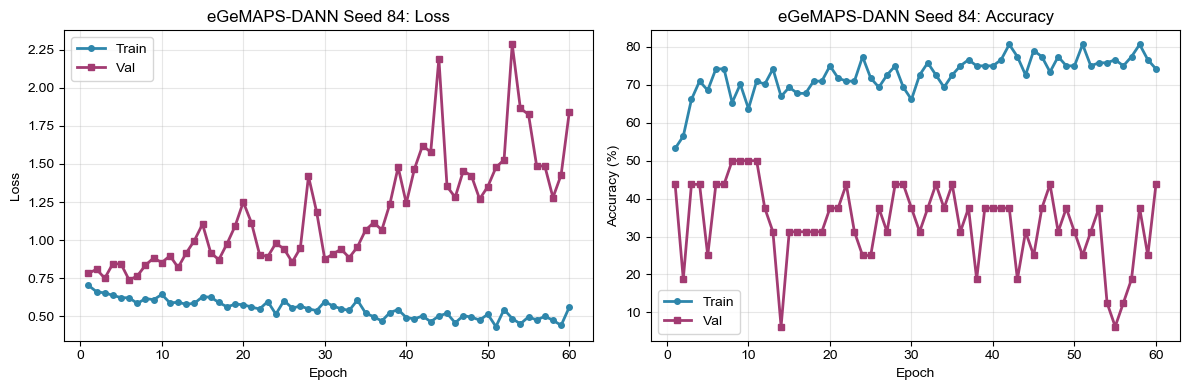

Evaluating Best Model (Seed 84)
Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         56.25%      0.6316       75.00%       37.50%    0.7992
Lu (target domain)             50.00%      0.6000       75.00%       25.00%    0.7753
-------------------------------------------------------------------------------------


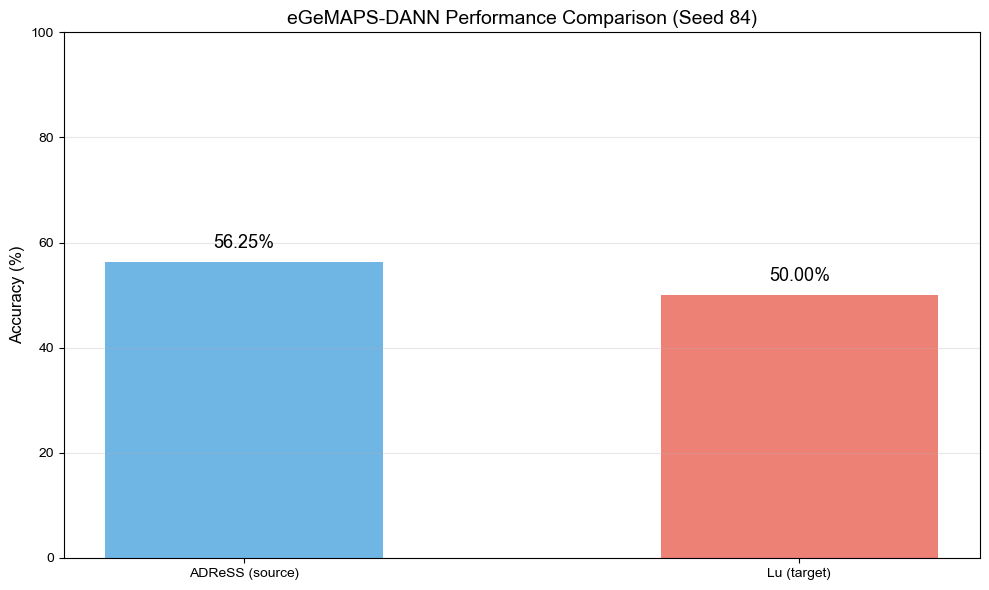

In [17]:
seed, metrics, history = train_dann(84, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT,
                                     min_source_acc=MIN_SOURCE_ACC, min_target_acc=MIN_TARGET_ACC)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'eGeMAPS-DANN Seed {seed}')

model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


### Seed 168



Training Seed 168
Model Selection: Average Accuracy (Source 0.500, Target 0.500)
Accuracy Thresholds: Source >= 0.60, Target >= 0.50


Epoch   1 | Train: 0.516 | Source Val: 0.531 | Target Val: 0.500 | Avg: 0.516 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.589 | Source Val: 0.531 | Target Val: 0.500 | Avg: 0.516 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.621 | Source Val: 0.375 | Target Val: 0.438 | Avg: 0.406 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.597 | Source Val: 0.469 | Target Val: 0.125 | Avg: 0.297 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  56 | Train: 0.710 | Source Val: 0.500 | Target Val: 0.438 | Avg: 0.469 | Domain: 0.552 | λ_dom: 1.000


Epoch  57 | Train: 0.718 | Source Val: 0.531 | Target Val: 0.375 | Avg: 0.453 | Domain: 0.468 | λ_dom: 1.000


Epoch  58 | Train: 0.758 | Source Val: 0.531 | Target Val: 0.438 | Avg: 0.484 | Domain: 0.548 | λ_dom: 1.000


Epoch  59 | Train: 0.798 | Source Val: 0.531 | Target Val: 0.438 | Avg: 0.484 | Domain: 0.524 | λ_dom: 1.000


Epoch  60 | Train: 0.726 | Source Val: 0.500 | Target Val: 0.375 | Avg: 0.438 | Domain: 0.456 | λ_dom: 1.000

Best Results (Epoch 33):
  Avg Acc: 60.94%
  Source (ADReSS): 65.62% | F1: 0.7027
  Target (Lu): 56.25% | F1: 0.6667


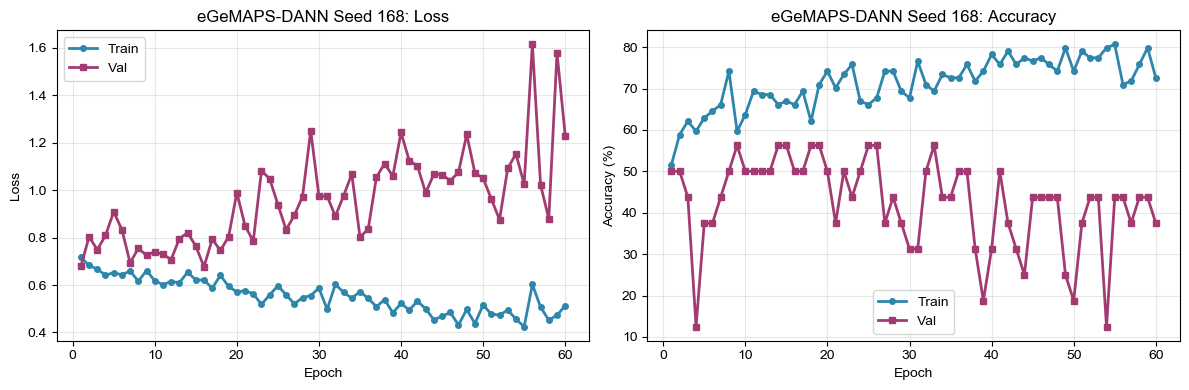

Evaluating Best Model (Seed 168)
Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         65.62%      0.7027       81.25%       50.00%    0.7385
Lu (target domain)             56.25%      0.6667       87.50%       25.00%    0.9115
-------------------------------------------------------------------------------------


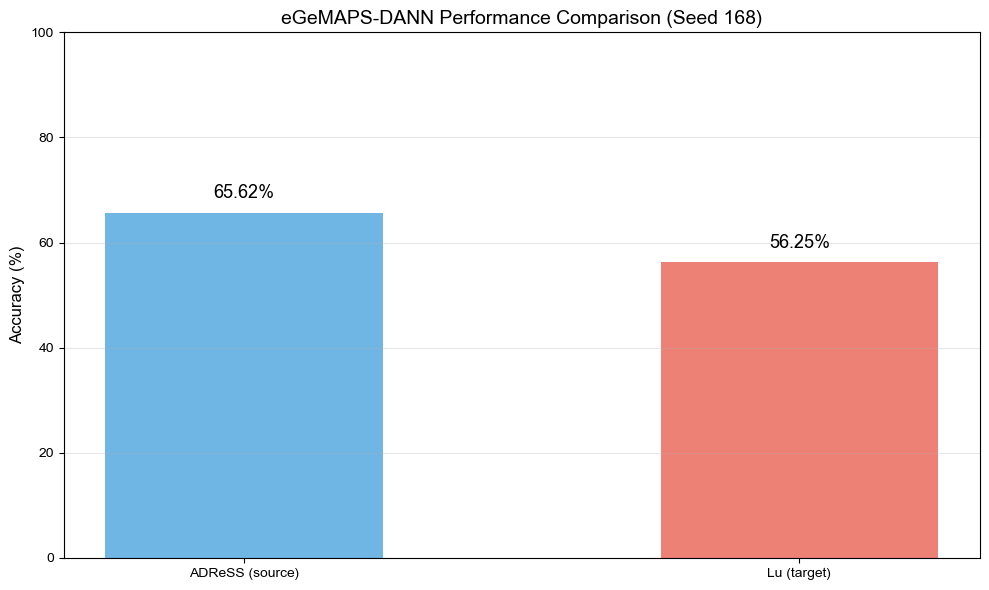

In [18]:
seed, metrics, history = train_dann(168, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT,
                                     min_source_acc=MIN_SOURCE_ACC, min_target_acc=MIN_TARGET_ACC)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'eGeMAPS-DANN Seed {seed}')

model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


### Seed 336



Training Seed 336
Model Selection: Average Accuracy (Source 0.500, Target 0.500)
Accuracy Thresholds: Source >= 0.60, Target >= 0.50


Epoch   1 | Train: 0.532 | Source Val: 0.469 | Target Val: 0.125 | Avg: 0.297 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.565 | Source Val: 0.406 | Target Val: 0.188 | Avg: 0.297 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.581 | Source Val: 0.406 | Target Val: 0.438 | Avg: 0.422 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.677 | Source Val: 0.500 | Target Val: 0.438 | Avg: 0.469 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  56 | Train: 0.806 | Source Val: 0.531 | Target Val: 0.188 | Avg: 0.359 | Domain: 0.496 | λ_dom: 1.000


Epoch  57 | Train: 0.734 | Source Val: 0.531 | Target Val: 0.500 | Avg: 0.516 | Domain: 0.456 | λ_dom: 1.000


Epoch  58 | Train: 0.823 | Source Val: 0.469 | Target Val: 0.438 | Avg: 0.453 | Domain: 0.508 | λ_dom: 1.000


Epoch  59 | Train: 0.798 | Source Val: 0.531 | Target Val: 0.312 | Avg: 0.422 | Domain: 0.452 | λ_dom: 1.000


Epoch  60 | Train: 0.798 | Source Val: 0.469 | Target Val: 0.375 | Avg: 0.422 | Domain: 0.476 | λ_dom: 1.000

Best Results (Epoch 33):
  Avg Acc: 62.50%
  Source (ADReSS): 62.50% | F1: 0.6667
  Target (Lu): 62.50% | F1: 0.7000


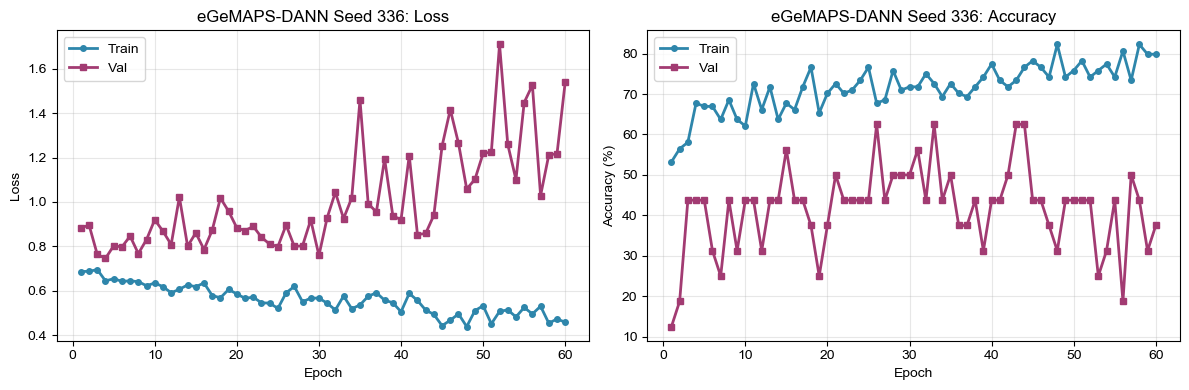

Evaluating Best Model (Seed 336)
Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         62.50%      0.6667       75.00%       50.00%    0.7863
Lu (target domain)             62.50%      0.7000       87.50%       37.50%    0.9923
-------------------------------------------------------------------------------------


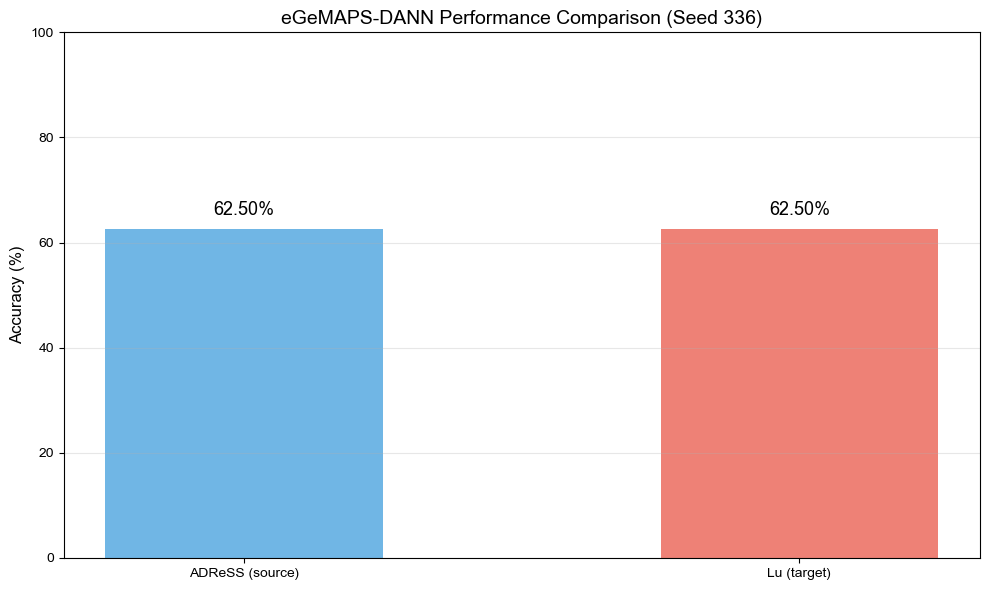

In [19]:
seed, metrics, history = train_dann(336, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT,
                                     min_source_acc=MIN_SOURCE_ACC, min_target_acc=MIN_TARGET_ACC)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'eGeMAPS-DANN Seed {seed}')

model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


## 5 Summary and Visualization


In [20]:
seeds = all_results['seeds']

# Source domain results
source_accs = [m['acc'] * 100 for m in all_results['source_metrics']]
source_f1s = [m['f1'] for m in all_results['source_metrics']]
source_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['source_metrics']]
source_control_accs = [m['control_acc'] * 100 for m in all_results['source_metrics']]
source_losses = [m['loss'] for m in all_results['source_metrics']]

# Target domain results
target_accs = [m['acc'] * 100 for m in all_results['target_metrics']]
target_f1s = [m['f1'] for m in all_results['target_metrics']]
target_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['target_metrics']]
target_control_accs = [m['control_acc'] * 100 for m in all_results['target_metrics']]
target_losses = [m['loss'] for m in all_results['target_metrics']]

print(f"{'Dataset':<25} {'Mean Acc':<20} {'Mean F1':<20} {'Mean Loss':<15}")
print(f"{'-'*90}")
print(f"{f'{SOURCE_DATASET} (source domain)':<25} {np.mean(source_accs):>6.2f}% ± {np.std(source_accs):>4.2f}%  {np.mean(source_f1s):>8.4f} ± {np.std(source_f1s):>6.4f}  {np.mean(source_losses):>10.4f}")
print(f"{f'{TARGET_DATASET} (target domain)':<25} {np.mean(target_accs):>6.2f}% ± {np.std(target_accs):>4.2f}%  {np.mean(target_f1s):>8.4f} ± {np.std(target_f1s):>6.4f}  {np.mean(target_losses):>10.4f}")
print(f"{'-'*90}\\n")

print(f"{'Seed':<8} {'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
print(f"{'-'*90}")
for i, seed in enumerate(seeds):
    print(f"{seed:<8} {f'{SOURCE_DATASET} (source domain)':<25} {source_accs[i]:>10.2f}%  {source_f1s[i]:>10.4f}  {source_dementia_accs[i]:>10.2f}%  {source_control_accs[i]:>10.2f}%  {source_losses[i]:>8.4f}")
    print(f"{'':<8} {f'{TARGET_DATASET} (target domain)':<25} {target_accs[i]:>10.2f}%  {target_f1s[i]:>10.4f}  {target_dementia_accs[i]:>10.2f}%  {target_control_accs[i]:>10.2f}%  {target_losses[i]:>8.4f}")
    print(f"{'-'*90}")


Dataset                   Mean Acc             Mean F1              Mean Loss      
------------------------------------------------------------------------------------------
ADReSS (source domain)     60.62% ± 3.75%    0.6327 ± 0.0491      0.7696
Lu (target domain)         57.50% ± 4.68%    0.6253 ± 0.0494      0.8376
------------------------------------------------------------------------------------------\n
Seed     Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
------------------------------------------------------------------------------------------
21       ADReSS (source domain)         62.50%      0.6000       56.25%       68.75%    0.7440
         Lu (target domain)             62.50%      0.5714       50.00%       75.00%    0.7521
------------------------------------------------------------------------------------------
42       ADReSS (source domain)         56.25%      0.5625       56.25%       56.25%    0.7800
         Lu (target d

In [21]:
torch.cuda.empty_cache()
